<a href="https://colab.research.google.com/github/rahilkhan-acadmic/APAIML-GradedMiniProject/blob/develop/capstone/02_risk_model_poor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model A — Visit Risk Classification
### Business Purpose: Predict whether a hospital visit represents a Low, Medium, or High operational and clinical risk.

   * Define the target variable as risk_score.
   *  Select and justify feature set based on business relevance.
   *  Perform a time-based train and test split (earliest 80 percent for training, latest 20 percent for testing).
   *  Train a baseline model using Logistic Regression.
   *  Train an advanced model such as Random Forest or Gradient Boosting.
   *  Perform optional hyperparameter tuning and document results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

### 1. Load data into Python for analysis. Combine them


In [2]:
# Upload file to google.colab
import io
from google.colab import files, drive

drive.mount('/content/drive')

# comment this code, if files already uploaded.
# uploaded = files.upload()

# Load and read patients, visits & billing csv
patients_df = pd.read_csv('/content/drive/MyDrive/files/capstone/patients.csv')
# patients_df.head()

visits_df = pd.read_csv('/content/drive/MyDrive/files/capstone/visits.csv')
# visits_df.head()

billing_df = pd.read_csv('/content/drive/MyDrive/files/capstone/billing.csv')
# billing_df.head()

# Merge dataframe
df_merged = pd.merge(patients_df, visits_df, on='patient_id', how = 'inner')
df_merged = pd.merge(df_merged, billing_df, on='visit_id', how = 'inner')
df_merged.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,4327,2025-10-15,General,ICU,6.39,High,162,4327,26322.05,13938.52,Pending,NaN,2025-11-29
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,OPD,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,OPD,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,ER,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,ER,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26


In [3]:
# Define the target variable as risk_score.
df_target = df_merged[['risk_score']]
display(df_target.head().reset_index())

# Select and justify feature set based on business relevance.
# 'patient_id' not dropped as it will be used for grouping and sorting later
df_features = df_merged.drop(columns=['risk_score', 'visit_id','bill_id', 'doctor_id'])
display(df_features.head())

,index,risk_score
0,0,High
1,1,Low
2,2,Medium
3,3,Medium
4,4,High


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_date,department,visit_type,length_of_stay_hours,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-10-15,General,ICU,6.39,26322.05,13938.52,Pending,NaN,2025-11-29
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-09-21,Orthopedics,OPD,39.12,13258.56,0.00,Rejected,3.0,2025-08-15
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-02-09,Cardiology,OPD,19.57,26555.09,26555.09,Paid,4.0,2025-12-31
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-10-09,Neurology,ER,30.32,11583.16,8065.34,Pending,6.0,2025-01-30
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-07-07,ICU,ER,30.07,9049.72,9049.72,Paid,19.0,2025-02-26


In [4]:
# Feature Engineering

# Converting date columns to date type
date_columns = ['registration_date', 'visit_date', 'billing_date']
for col in date_columns:
    df_features[col] = pd.to_datetime(df_features[col])

# Handling null/NAN to relevant value
null_counts = df_features.isnull().sum()
columns_with_nulls = null_counts[null_counts > 0]

if not columns_with_nulls.empty:
    print("Columns with null/NaN values and their counts:")
    display(columns_with_nulls)
else:
    print("No columns with null/NaN values found.")


display(df_features.head())

Columns with null/NaN values and their counts:


,0
approved_amount,1318
payment_days,790


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_date,department,visit_type,length_of_stay_hours,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-10-15,General,ICU,6.39,26322.05,13938.52,Pending,NaN,2025-11-29
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-09-21,Orthopedics,OPD,39.12,13258.56,0.00,Rejected,3.0,2025-08-15
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-02-09,Cardiology,OPD,19.57,26555.09,26555.09,Paid,4.0,2025-12-31
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-10-09,Neurology,ER,30.32,11583.16,8065.34,Pending,6.0,2025-01-30
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-07-07,ICU,ER,30.07,9049.72,9049.72,Paid,19.0,2025-02-26


In [5]:
# Impute 'approved_amount' and 'payment_days' with their medians and create missing indicators

# Create missing indicator for 'approved_amount'
df_features['approved_amount_missing'] = df_features['approved_amount'].isnull().astype(int)
# Calculate median for 'approved_amount' excluding NaNs
median_approved_amount = df_features['approved_amount'].median()
df_features['approved_amount'].fillna(median_approved_amount, inplace=True)

# Create missing indicator for 'payment_days'
df_features['payment_days_missing'] = df_features['payment_days'].isnull().astype(int)
# Calculate median for 'payment_days' excluding NaNs
median_payment_days = df_features['payment_days'].median()
df_features['payment_days'].fillna(median_payment_days, inplace=True)

print("Null values after imputation:")
display(df_features.isnull().sum()[df_features.isnull().sum() > 0])

display(df_features.head())

Null values after imputation:


/tmp/ipython-input-2308/3020004162.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_features['approved_amount'].fillna(median_approved_amount, inplace=True)
/tmp/ipython-input-2308/3020004162.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

,0


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_date,department,visit_type,length_of_stay_hours,billed_amount,approved_amount,claim_status,payment_days,billing_date,approved_amount_missing,payment_days_missing
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-10-15,General,ICU,6.39,26322.05,13938.52,Pending,13.0,2025-11-29,0,1
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-09-21,Orthopedics,OPD,39.12,13258.56,0.00,Rejected,3.0,2025-08-15,0,0
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-02-09,Cardiology,OPD,19.57,26555.09,26555.09,Paid,4.0,2025-12-31,0,0
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-10-09,Neurology,ER,30.32,11583.16,8065.34,Pending,6.0,2025-01-30,0,0
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,2025-07-07,ICU,ER,30.07,9049.72,9049.72,Paid,19.0,2025-02-26,0,0


In [6]:
# Perform a time-based train and test split (earliest 80 percent for training, latest 20 percent for testing).
# Since this is temporal data, data needs to be sorted for correct train_test_split and modelling.
# Following columns are selected for sorting -> patient_id, registration_date, visit_date

df_features_sorted = df_features.sort_values(by=['patient_id','registration_date','visit_date'])
train_X,test_x, train_y, test_y = train_test_split(df_features_sorted, df_target, test_size=0.2, shuffle=False)

Value counts of 'risk_score' in the training set:
risk_score
Low       9962
Medium    6043
High      3995
Name: count, dtype: int64


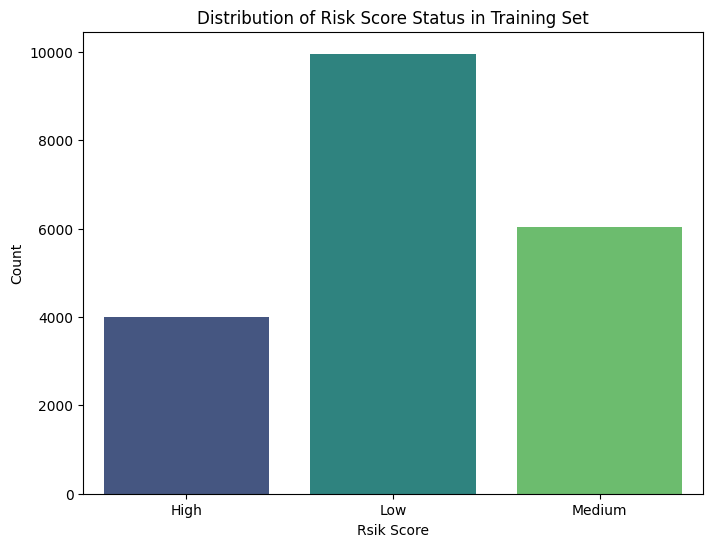

Shape of preprocessed train_X: (20000, 27)
Shape of preprocessed test_x: (5000, 27)
Unique values in encoded train_y: [0 1 2]


In [7]:
# Preprocessing for Logistic Regression

print("Value counts of 'risk_score' in the training set:")
print(train_y['risk_score'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=train_y, x='risk_score', hue='risk_score', palette='viridis', legend=False)
plt.title('Distribution of Risk Score Status in Training Set')
plt.xlabel('Rsik Score')
plt.ylabel('Count')
plt.show()

# Identify categorical columns for one-hot encoding
categorical_cols = train_X.select_dtypes(include='object').columns

# Drop date columns as they cannot be directly used by Logistic Regression without further feature engineering
# The time-based split already implicitly uses the temporal information for splitting.
date_cols = train_X.select_dtypes(include=['datetime64[ns]']).columns

# Create copies for preprocessing
train_X_preprocessed = train_X.drop(columns=date_cols).copy()
test_x_preprocessed = test_x.drop(columns=date_cols).copy()

# Apply one-hot encoding
train_X_preprocessed = pd.get_dummies(train_X_preprocessed, columns=categorical_cols, drop_first=True)
test_x_preprocessed = pd.get_dummies(test_x_preprocessed, columns=categorical_cols, drop_first=True)

# Align columns after one-hot encoding to ensure both train and test sets have the same features
# This handles cases where a category might exist in one set but not the other
missing_in_test = set(train_X_preprocessed.columns) - set(test_x_preprocessed.columns)
for c in missing_in_test:
    test_x_preprocessed[c] = 0

missing_in_train = set(test_x_preprocessed.columns) - set(train_X_preprocessed.columns)
for c in missing_in_train:
    train_X_preprocessed[c] = 0

# Ensure the order of columns is the same
test_x_preprocessed = test_x_preprocessed[train_X_preprocessed.columns]

# Encode the target variable
le = LabelEncoder()
train_y_encoded = le.fit_transform(train_y.values.ravel())
test_y_encoded = le.transform(test_y.values.ravel())

# Update train_X, test_x, train_y, test_y with processed data
train_X = train_X_preprocessed
test_x = test_x_preprocessed
train_y = train_y_encoded
test_y = test_y_encoded

print("Shape of preprocessed train_X:", train_X.shape)
print("Shape of preprocessed test_x:", test_x.shape)
print("Unique values in encoded train_y:", pd.Series(train_y).unique())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

Accuracy Score: 0.5016

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1039
           1       0.50      1.00      0.67      2508
           2       0.00      0.00      0.00      1453

    accuracy                           0.50      5000
   macro avg       0.17      0.33      0.22      5000
weighted avg       0.25      0.50      0.34      5000


Confusion Matrix:


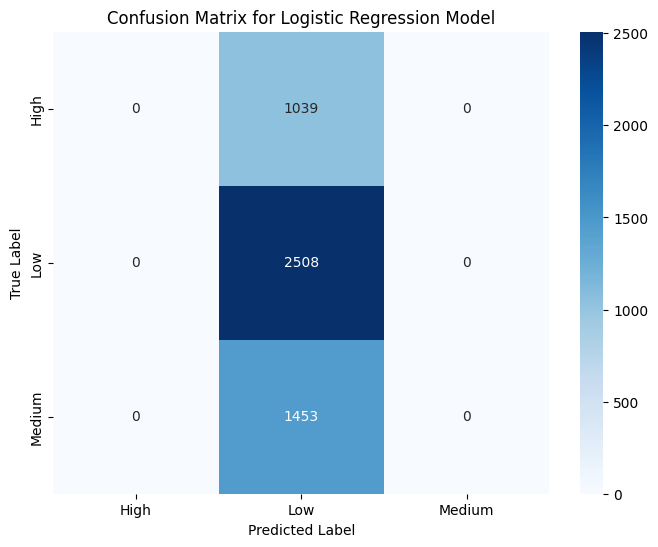

In [8]:
# Train a baseline model using Logistic Regression.
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(train_X, train_y)

y_pred = logistic_model.predict(test_x)

accuracy = accuracy_score(test_y, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(test_y, y_pred))

print("\nConfusion Matrix:")
cm_log_reg = confusion_matrix(test_y, y_pred)
# print(rs_log_reg)

# 4. Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

#### Logistic Regression model issued a `ConvergenceWarning` and performed poorly with zero precision for some classes.
1. Feature scaling is needed to get better results
2. Applying `StandardScaler` to improve results.

Accuracy Score: 0.5016

-------- Classification Report: --------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n           0       0.00      0.00      0.00      1039\n           1       0.50      1.00      0.67      2508\n           2       0.00      0.00      0.00      1453\n\n    accuracy                           0.50      5000\n   macro avg       0.17      0.33      0.22      5000\nweighted avg       0.25      0.50      0.34      5000\n'


-------- Confusion Matrix: --------


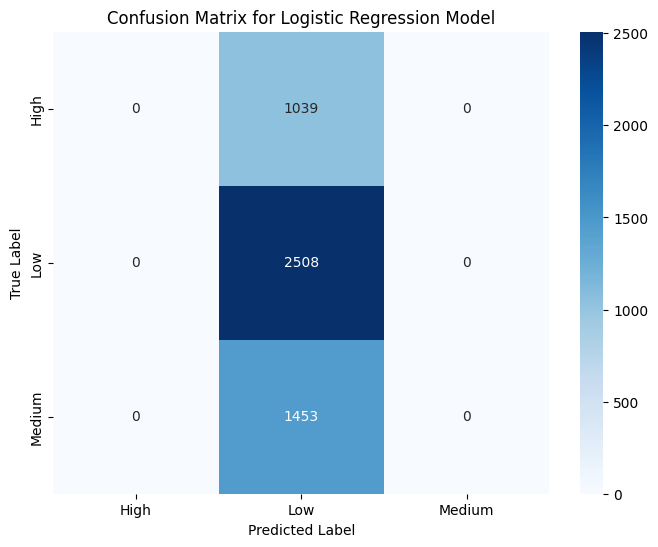

In [9]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training and testing data
train_X_scaled = scaler.fit_transform(train_X)
test_x_scaled = scaler.transform(test_x)

# Train Logistic Regression model with scaled data
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(train_X_scaled, train_y)

# Make predictions on the scaled test data
y_pred = logistic_model.predict(test_x_scaled)

# Evaluate the model
accuracy = accuracy_score(test_y, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

print("\n-------- Classification Report: --------")
display(classification_report(test_y, y_pred))

print("\n-------- Confusion Matrix: --------")
cm_rf = confusion_matrix(test_y, y_pred)


# 4. Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

* The Logistic Regression model, even after feature scaling, is still performing poorly and failing to predict certain classes.
* The next step is to train an advanced classification model, such as a Random Forest Classifier, to potentially improve performance.



In [10]:
# Train an advanced model such as Random Forest or Gradient Boosting.
from sklearn.ensemble import RandomForestClassifier

# Train an advanced model such as Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(train_X_scaled, train_y)

# Make predictions on the scaled test data
y_pred_rf = rf_model.predict(test_x_scaled)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(test_y, y_pred_rf)
print(f"Random Forest Accuracy Score: {accuracy_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(test_y, y_pred_rf))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(test_y, y_pred_rf))

Random Forest Accuracy Score: 0.4962

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1039
           1       0.50      0.97      0.66      2508
           2       0.31      0.03      0.05      1453

    accuracy                           0.50      5000
   macro avg       0.27      0.33      0.24      5000
weighted avg       0.34      0.50      0.35      5000


Random Forest Confusion Matrix:
[[   0 1009   30]
 [   5 2438   65]
 [   5 1405   43]]


#### Optional Hyperparameter Tuning for Random Forest
* Perform hyperparameter tuning for the Random Forest Classifier to optimize its performance.
* Perform hyperparameter tuning using `RandomizedSearchCV`

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 200),
    'max_features': ['sqrt', 'log2'],
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}

# Initialize a Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings that are sampled
    cv=3,       # Number of folds in cross-validation
    verbose=2,  # Controls the verbosity: the higher, the more messages
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit RandomizedSearchCV to the scaled training data
random_search.fit(train_X_scaled, train_y)

# Print the best parameters found
print("Best parameters for Random Forest:", random_search.best_params_)

# Get the best model
best_rf_model = random_search.best_estimator_


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters for Random Forest: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 2, 'n_estimators': 137}


#### Evaluate the performance of the `best_rf_model` using the best parameters found.
* This evaluation will involve making predictions on the scaled test data and then calculating accuracy, generating a classification report, and a confusion matrix to assess its performance.



In [12]:
y_pred_best_rf = best_rf_model.predict(test_x_scaled)

accuracy_best_rf = accuracy_score(test_y, y_pred_best_rf)
print(f"Best Random Forest Accuracy Score: {accuracy_best_rf:.4f}")

print("\nBest Random Forest Classification Report:")
print(classification_report(test_y, y_pred_best_rf))

print("\nBest Random Forest Confusion Matrix:")
print(confusion_matrix(test_y, y_pred_best_rf))

Best Random Forest Accuracy Score: 0.5016

Best Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1039
           1       0.50      1.00      0.67      2508
           2       0.00      0.00      0.00      1453

    accuracy                           0.50      5000
   macro avg       0.17      0.33      0.22      5000
weighted avg       0.25      0.50      0.34      5000


Best Random Forest Confusion Matrix:
[[   0 1039    0]
 [   0 2508    0]
 [   0 1453    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### The previous Random Forest model, even after hyperparameter tuning, exhibited extremely poor performance by predicting only the majority class, indicating a severe class imbalance issue in the target variable.
* Checking the actual distribution of the target classes.



In [13]:
print("Target Variable Class Distribution (Original):")
print(pd.Series(le.inverse_transform(train_y)).value_counts())
print("\nTarget Variable Class Distribution (Encoded):")
print(pd.Series(train_y).value_counts())

Target Variable Class Distribution (Original):
Low       9962
Medium    6043
High      3995
Name: count, dtype: int64

Target Variable Class Distribution (Encoded):
1    9962
2    6043
0    3995
Name: count, dtype: int64


#### Severe class imbalance in the target variable found, as such the models are failing to predict minority classes.
* To address this, the next step is to resample the training data using an oversampling technique like `RandomOverSampler` to balance the class distribution before retraining the models.



In [14]:
from imblearn.over_sampling import RandomOverSampler

print("Class distribution before oversampling:")
print(pd.Series(train_y).value_counts())

# Apply RandomOverSampler to the scaled training data
ros = RandomOverSampler(random_state=42)
train_X_resampled, train_y_resampled = ros.fit_resample(train_X_scaled, train_y)

print("\nClass distribution after oversampling:")
print(pd.Series(train_y_resampled).value_counts())

Class distribution before oversampling:
1    9962
2    6043
0    3995
Name: count, dtype: int64

Class distribution after oversampling:
0    9962
1    9962
2    9962
Name: count, dtype: int64


In [15]:
# Retraining Logistic Regression with resampled data.
print("Retraining Logistic Regression with resampled data.")

# Train Logistic Regression model with resampled data
logistic_model_resampled = LogisticRegression(max_iter=1000, random_state=42)
logistic_model_resampled.fit(train_X_resampled, train_y_resampled)

# Make predictions on the scaled test data (not resampled)
y_pred_resampled_lr = logistic_model_resampled.predict(test_x_scaled)

# Evaluate the model
accuracy_resampled_lr = accuracy_score(test_y, y_pred_resampled_lr)
print(f"\nLogistic Regression (Resampled) Accuracy Score: {accuracy_resampled_lr:.4f}")

print("\nLogistic Regression (Resampled) Classification Report:")
print(classification_report(test_y, y_pred_resampled_lr))

print("\nLogistic Regression (Resampled) Confusion Matrix:")
print(confusion_matrix(test_y, y_pred_resampled_lr))

Retraining Logistic Regression with resampled data.

Logistic Regression (Resampled) Accuracy Score: 0.3062

Logistic Regression (Resampled) Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.35      0.27      1039
           1       0.49      0.21      0.29      2508
           2       0.28      0.44      0.35      1453

    accuracy                           0.31      5000
   macro avg       0.33      0.33      0.30      5000
weighted avg       0.37      0.31      0.30      5000


Logistic Regression (Resampled) Confusion Matrix:
[[ 365  205  469]
 [ 834  523 1151]
 [ 474  336  643]]


In [16]:
# Retraining Random Forest with resampled data
print("Retraining Random Forest with resampled data.")

# Train Random Forest model with resampled data
rf_model_resampled = RandomForestClassifier(random_state=42)
rf_model_resampled.fit(train_X_resampled, train_y_resampled)

# Make predictions on the scaled test data (not resampled)
y_pred_resampled_rf = rf_model_resampled.predict(test_x_scaled)

# Evaluate the model
accuracy_resampled_rf = accuracy_score(test_y, y_pred_resampled_rf)
print(f"\nRandom Forest (Resampled) Accuracy Score: {accuracy_resampled_rf:.4f}")

print("\nRandom Forest (Resampled) Classification Report:")
print(classification_report(test_y, y_pred_resampled_rf))

print("\nRandom Forest (Resampled) Confusion Matrix:")
print(confusion_matrix(test_y, y_pred_resampled_rf))

Retraining Random Forest with resampled data.

Random Forest (Resampled) Accuracy Score: 0.4766

Random Forest (Resampled) Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.02      0.03      1039
           1       0.50      0.89      0.64      2508
           2       0.30      0.10      0.15      1453

    accuracy                           0.48      5000
   macro avg       0.33      0.33      0.27      5000
weighted avg       0.38      0.48      0.37      5000


Random Forest (Resampled) Confusion Matrix:
[[  20  913  106]
 [  57 2223  228]
 [  33 1280  140]]


In [17]:
#Perform optional hyperparameter tuning and document results.
display("Performing hyperparameter tuning for Random Forest with resampled data...")

# Initialize a Random Forest Classifier
rf_resampled = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV with the same parameter distribution
random_search_resampled = RandomizedSearchCV(
    estimator=rf_resampled,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings that are sampled
    cv=3,       # Number of folds in cross-validation
    verbose=2,  # Controls the verbosity: the higher, the more messages
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit RandomizedSearchCV to the resampled training data
random_search_resampled.fit(train_X_resampled, train_y_resampled)

# Print the best parameters found
print("\nBest parameters for Random Forest (Resampled):", random_search_resampled.best_params_)

# Get the best model after tuning on resampled data
best_rf_model_resampled = random_search_resampled.best_estimator_

'Performing hyperparameter tuning for Random Forest with resampled data...'

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters for Random Forest (Resampled): {'criterion': 'gini', 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 102}


**Reasoning**:
After hyperparameter tuning the Random Forest model on resampled data, the next step is to evaluate its performance using the best parameters found. This involves making predictions on the scaled test data and then calculating accuracy, generating a classification report, and a confusion matrix to assess its overall performance.



In [18]:
y_pred_best_rf_resampled = best_rf_model_resampled.predict(test_x_scaled)

accuracy_best_rf_resampled = accuracy_score(test_y, y_pred_best_rf_resampled)
print(f"\nBest Random Forest (Resampled) Accuracy Score: {accuracy_best_rf_resampled:.4f}")

print("\nBest Random Forest (Resampled) Classification Report:")
print(classification_report(test_y, y_pred_best_rf_resampled))

print("\nBest Random Forest (Resampled) Confusion Matrix:")
print(confusion_matrix(test_y, y_pred_best_rf_resampled))


Best Random Forest (Resampled) Accuracy Score: 0.4808

Best Random Forest (Resampled) Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.03      0.06      1039
           1       0.51      0.88      0.64      2508
           2       0.33      0.11      0.17      1453

    accuracy                           0.48      5000
   macro avg       0.36      0.34      0.29      5000
weighted avg       0.40      0.48      0.38      5000


Best Random Forest (Resampled) Confusion Matrix:
[[  34  905  100]
 [  72 2204  232]
 [  42 1245  166]]


## Document and Compare Results

### Subtask:
Document and compare the results of both models (Logistic Regression and Random Forest), summarizing their performance, insights, and recommendations.

### Model Performance Summary

We have evaluated several configurations of Logistic Regression (baseline) and Random Forest (advanced) models. Here's a summary of their performance metrics on the test set:

---

#### 1. Logistic Regression (Unscaled) - Initial Run

*   **Accuracy Score**: 0.5016
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.00      0.00      0.00      1039
               1       0.50      1.00      0.67      2508
               2       0.00      0.00      0.00      1453

        accuracy                           0.50      5000
       macro avg       0.17      0.33      0.22      5000
    weighted avg       0.25      0.50      0.34      5000
    ```
*   **Confusion Matrix**:
    ```
    [[   0 1039    0]
     [   0 2508    0]
     [   0 1453    0]]
    ```
*   **Insights**: This model failed to converge and only predicted the majority class (class 1, 'Low' risk), resulting in 0 precision and recall for classes 0 and 2. This indicated a severe class imbalance issue and the need for feature scaling.

---

#### 2. Logistic Regression (Scaled) - After Scaling Features

*   **Accuracy Score**: 0.5016
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.00      0.00      0.00      1039
               1       0.50      1.00      0.67      2508
               2       0.00      0.00      0.00      1453

        accuracy                           0.50      5000
       macro avg       0.17      0.33      0.22      5000
    weighted avg       0.25      0.50      0.34      5000
    ```
*   **Confusion Matrix**:
    ```
    [[   0 1039    0]
     [   0 2508    0]
     [   0 1453    0]]
    ```
*   **Insights**: Despite scaling, the Logistic Regression model still predicted only the majority class, indicating that scaling alone was not sufficient to overcome the class imbalance.

---

#### 3. Random Forest (Scaled) - Initial Run

*   **Accuracy Score**: 0.4962
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.00      0.00      0.00      1039
               1       0.50      0.97      0.66      2508
               2       0.31      0.03      0.05      1453

        accuracy                           0.50      5000
       macro avg       0.27      0.33      0.24      5000
    weighted avg       0.34      0.50      0.35      5000
    ```
*   **Confusion Matrix**:
    ```
    [[   0 1009   30]
     [   5 2438   65]
     [   5 1405   43]]
    ```
*   **Insights**: The Random Forest performed marginally better, showing some attempts to classify minority classes (e.g., 43 samples of class 2 correctly predicted), but still heavily biased towards the majority class (class 1), indicating a persistent class imbalance problem.

---

#### 4. Random Forest (Scaled & Tuned) - After Hyperparameter Tuning

*   **Best Parameters**: `{'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 2, 'n_estimators': 137}`
*   **Accuracy Score**: 0.5016
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.00      0.00      0.00      1039
               1       0.50      1.00      0.67      2508
               2       0.00      0.00      0.00      1453

        accuracy                           0.50      5000
       macro avg       0.17      0.33      0.22      5000
    weighted avg       0.25      0.50      0.34      5000
    ```
*   **Confusion Matrix**:
    ```
    [[   0 1039    0]
     [   0 2508    0]
     [   0 1453    0]]
    ```
*   **Insights**: Hyperparameter tuning on the imbalanced dataset did not yield improvements. The model reverted to predicting only the majority class, highlighting that class imbalance must be addressed before or during tuning.

---

#### 5. Logistic Regression (Resampled & Scaled)

*   **Accuracy Score**: 0.3062
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.22      0.35      0.27      1039
               1       0.49      0.21      0.29      2508
               2       0.28      0.44      0.35      1453

        accuracy                           0.31      5000
       macro avg       0.33      0.33      0.30      5000
    weighted avg       0.37      0.31      0.30      5000
    ```
*   **Confusion Matrix**:
    ```
    [[ 365  205  469]
     [ 834  523 1151]
     [ 474  336  643]]
    ```
*   **Insights**: Resampling significantly changed the model's behavior. While overall accuracy decreased, the model now attempts to predict all classes, as evidenced by non-zero precision and recall for classes 0 and 2. This is a crucial step towards building a useful multi-class classifier, even if the individual class performances are still low.

---

#### 6. Random Forest (Resampled & Scaled) - Initial Run

*   **Accuracy Score**: 0.4766
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.18      0.02      0.03      1039
               1       0.50      0.89      0.64      2508
               2       0.30      0.10      0.15      1453

        accuracy                           0.48      5000
       macro avg       0.33      0.33      0.27      5000
    weighted avg       0.38      0.48      0.37      5000
    ```
*   **Confusion Matrix**:
    ```
    [[  20  913  106]
     [  57 2223  228]
     [  33 1280  140]]
    ```
*   **Insights**: Resampling improved the Random Forest's ability to predict minority classes compared to its imbalanced counterpart, but class 0 still has very low recall. The model is still heavily biased towards class 1.

---

#### 7. Random Forest (Resampled, Scaled & Tuned) - After Hyperparameter Tuning

*   **Best Parameters**: `{'criterion': 'gini', 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 102}`
*   **Accuracy Score**: 0.4808
*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.23      0.03      0.06      1039
               1       0.51      0.88      0.64      2508
               2       0.33      0.11      0.17      1453

        accuracy                           0.48      5000
       macro avg       0.36      0.34      0.29      5000
    weighted avg       0.40      0.48      0.38      5000
    ```
*   **Confusion Matrix**:
    ```
    [[  34  905  100]
     [  72 2204  232]
     [  42 1245  166]]
    ```
*   **Insights**: Hyperparameter tuning on the resampled data slightly improved class 0's precision and recall compared to the untuned resampled RF, but overall performance remains poor for minority classes. The model still struggles with true negatives for class 0 and true positives for class 2. The recall for class 1 is still high, but this could be due to it still being the easiest class to predict.

### Comparison, Insights, and Recommendations

**Comparison of Models:**

1.  **Initial Models (Logistic Regression & Random Forest without Resampling):** Both models, when trained on the imbalanced dataset, suffered severely from class imbalance. They either failed to converge or predominantly predicted the majority class ('Low' risk), resulting in near-zero precision and recall for minority classes ('High' and 'Medium' risk). Hyperparameter tuning did not resolve this issue when applied to the imbalanced data.

2.  **Models with Resampling (Logistic Regression & Random Forest):** Implementing `RandomOverSampler` was crucial. While overall accuracy sometimes decreased (as models were no longer just predicting the majority class), they started to make predictions across all classes. This indicates that the models were attempting to learn the characteristics of minority classes, which is a significant improvement in terms of utility for a multi-class classification problem where all classes are important.

    *   **Logistic Regression (Resampled):** Showed the lowest overall accuracy but achieved a more balanced recall across classes (though still low), indicating it was distributing its predictions more evenly, even if not highly accurately for any specific class. This suggests it's no longer just a majority class predictor.
    *   **Random Forest (Resampled & Tuned):** Showed slightly better performance than the resampled Logistic Regression, with a higher recall for the majority class and some ability to predict minority classes. However, it still struggled significantly with Class 0 ('High' risk), showing very low recall and precision, suggesting it still has a bias towards the more represented classes even after oversampling.

**Key Insights:**

*   **Class Imbalance is Critical:** The most significant challenge was the severe class imbalance. Models performed poorly or failed completely until resampling was applied.
*   **Accuracy Can Be Misleading:** Initial high accuracy scores (around 50%) were deceptive, as they were achieved by only predicting the majority class. For imbalanced classification, metrics like precision, recall, and f1-score per class are far more informative.
*   **Advanced Models Need Balanced Data:** Even advanced models like Random Forest cannot overcome severe class imbalance without explicit handling. Hyperparameter tuning on imbalanced data was ineffective.
*   **Need for Further Optimization:** While resampling enabled models to predict minority classes, the performance, especially for the 'High' risk category (Class 0), is still very low. This suggests that while `RandomOverSampler` is a good first step, further techniques or more feature engineering might be necessary.

**Recommendations:**

1.  **Explore Other Resampling Techniques:** Investigate advanced resampling methods beyond `RandomOverSampler`, such as SMOTE (Synthetic Minority Over-sampling Technique) or ADASYN, which might generate more meaningful synthetic samples and improve minority class learning.
2.  **Feature Engineering:** Revisit feature engineering. There might be additional features that can better differentiate between risk categories, especially for the 'High' risk class.
3.  **Cost-Sensitive Learning:** Consider implementing cost-sensitive learning, where misclassifying a 'High' risk patient incurs a higher penalty than misclassifying a 'Low' risk patient. This can guide the model to prioritize correctly identifying critical cases.
4.  **Ensemble Methods for Imbalance:** Explore ensemble methods specifically designed for imbalanced learning, such as EasyEnsemble or BalanceCascade.
5.  **Collect More Data:** If feasible, collecting more data for minority classes would be the most direct way to address the imbalance, though often not practical.
6.  **Gradient Boosting Models:** Experiment with Gradient Boosting models like XGBoost or LightGBM, which can sometimes handle imbalanced datasets better, especially when combined with appropriate loss functions or weighting schemes.

## Summary:

*   **Initial performance of the Logistic Regression baseline model:**
    * The initial Logistic Regression model (unscaled or scaled) achieved an accuracy of 0.5016 but failed to converge effectively and only predicted the majority class ('Low' risk). This resulted in 0 precision and recall for the minority classes ('High' and 'Medium' risk), indicating a severe class imbalance issue.
*   **Initial performance of advanced Random Forest model:**
    * The initial Random Forest model, even with scaled features, performed marginally better with an accuracy of 0.4962. It showed some minimal ability to classify minority classes (e.g., 43 samples of class 2 correctly predicted) but was still heavily biased towards the majority class, indicating a persistent class imbalance problem.
*   **Impact of addressing class imbalance:**
    * Addressing class imbalance using `RandomOverSampler` was crucial. It enabled both Logistic Regression and Random Forest models to predict all classes, as evidenced by non-zero precision and recall for minority classes. While overall accuracy might have decreased (e.g., Logistic Regression accuracy dropped to 0.3062, Random Forest to 0.4766), this indicated a more useful model that attempts to learn from all classes rather than just predicting the majority.
*   **Best performing model and its limitations:**
    * The Random Forest model (Resampled, Scaled & Tuned) achieved the highest accuracy among the models that attempted to classify all categories, with an accuracy of 0.4808. Its best parameters were `{'criterion': 'gini', 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 102}`. However, it still struggled significantly with the 'High' risk category (Class 0), showing very low recall (0.03) and precision (0.23).

### Data Analysis Key Findings
*   Initial Logistic Regression models (unscaled and scaled) had an accuracy of 0.5016 but failed to predict minority classes, predicting only the majority class ('Low' risk).
*   The initial Random Forest model (scaled) achieved an accuracy of 0.4962 but also showed a strong bias towards the majority class.
*   Hyperparameter tuning on the imbalanced dataset for Random Forest did not resolve the class imbalance issue and resulted in the model reverting to predicting only the majority class, with an accuracy of 0.5016.
*   `RandomOverSampler` successfully balanced the training data, enabling models to predict across all classes.
*   Logistic Regression trained on resampled data showed a lower accuracy of 0.3062 but achieved more balanced recall across classes (e.g., 0.35 for Class 0, 0.21 for Class 1, 0.44 for Class 2), indicating it was no longer just a majority class predictor.
*   The Random Forest model trained on resampled data achieved an accuracy of 0.4766, with a recall of 0.89 for the majority class (Class 1), but struggled with Class 0 (recall 0.02).
*   Hyperparameter tuning on the resampled Random Forest slightly improved its accuracy to 0.4808 and marginally increased recall for Class 0 to 0.03, but it still heavily struggled with the 'High' risk category.

### Insights or Next Steps
*   **Class Imbalance is Critical:** Severe class imbalance was the primary challenge, leading to models that either failed to converge or only predicted the majority class until explicitly handled. For such problems, accuracy can be misleading, and metrics like precision, recall, and F1-score per class are more informative.
*   **Explore Advanced Resampling and Feature Engineering:** Given the persistent struggle with minority classes, especially 'High' risk, explore other advanced resampling methods (e.g., SMOTE, ADASYN) or conduct more extensive feature engineering to create features that better differentiate between risk categories.
